## Veri Bilimi Ara Ödev (İlk Ödev) - Ecrin Kaya

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)

In [45]:
!pip install -q gdown
import gdown
gdown.download('https://drive.google.com/uc?id=1rR1tG2lzCS20wKTkp0s9XZaK0iejjKL6', 'e_ticaret_veri_seti.csv', quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1rR1tG2lzCS20wKTkp0s9XZaK0iejjKL6
To: /content/e_ticaret_veri_seti.csv
100%|██████████| 202k/202k [00:00<00:00, 77.4MB/s]


'e_ticaret_veri_seti.csv'

In [46]:
## SORU 1 - Veri setini yükle, ilk 10 ve son 10 satır
df = pd.read_csv('e_ticaret_veri_seti.csv')
print(df.head(10))
print(df.tail(10))

  siparis_id musteri_id       siparis_tarihi      sehir              bolge  \
0  SIP101125    MUS1391  2024-01-13 17:06:00   İstanbul            Marmara   
1  SIP100837    MUS1347  2025-03-17 21:13:00  Gaziantep  Güneydoğu Anadolu   
2  SIP100050    MUS1066  2025-06-03 12:42:00    Kayseri         İç Anadolu   
3  SIP100263    MUS1008  2024-08-10 15:13:00    Antalya            Akdeniz   
4  SIP100707    MUS1291  2024-08-19 08:24:00  Gaziantep  Güneydoğu Anadolu   
5  SIP100687    MUS1147  2025-08-09 08:42:00      Konya         İç Anadolu   
6  SIP101351    MUS1011  2025-02-27 11:35:00   İstanbul            Marmara   
7  SIP101172    MUS1357  2024-07-22 13:26:00     Ankara         İç Anadolu   
8  SIP100779    MUS1354  2025-12-05 11:19:00   İstanbul            Marmara   
9  SIP100202    MUS1067  2024-05-11 22:53:00      Bursa            Marmara   

     kategori              urun_adi  adet  birim_fiyat  indirim_orani  \
0    Kozmetik          Nemlendirici     1       414.51           0.0

#### Yorum: Veri seti başarıyla yüklendi. Sipariş, müşteri, ürün ve ödeme bilgilerini içeren 18 sütunluk bir e-ticaret tablosu verildi.

In [47]:
## SORU 2 - Satır/sütun sayısı ve sütun isimleri
print("Satır sayısı:", df.shape[0])
print("Sütun sayısı:", df.shape[1])
print("Sütunlar:", list(df.columns))

Satır sayısı: 1428
Sütun sayısı: 18
Sütunlar: ['siparis_id', 'musteri_id', 'siparis_tarihi', 'sehir', 'bolge', 'kategori', 'urun_adi', 'adet', 'birim_fiyat', 'indirim_orani', 'kargo_ucreti', 'odeme_turu', 'musteri_tipi', 'teslimat_gunu', 'musteri_puani', 'iade_durumu', 'kar_marji_orani', 'toplam_tutar']


#### Yorum: Veri setinde toplam satır - sütun sayısı yukarıda görülüyor; sütun isimleri sipariş sürecinin tüm aşamalarını temsil ediyor.

In [48]:
## SORU 3 - info(), describe(), sayısal/kategorik sütunlar
print(df.info())
print(df.describe())

sayisal_sutunlar = df.select_dtypes(include=np.number).columns.tolist()
kategorik_sutunlar = df.select_dtypes(include='object').columns.tolist()
print("Sayısal sütunlar:", sayisal_sutunlar)
print("Kategorik sütunlar:", kategorik_sutunlar)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1428 entries, 0 to 1427
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   siparis_id       1428 non-null   object 
 1   musteri_id       1428 non-null   object 
 2   siparis_tarihi   1428 non-null   object 
 3   sehir            1403 non-null   object 
 4   bolge            1428 non-null   object 
 5   kategori         1428 non-null   object 
 6   urun_adi         1428 non-null   object 
 7   adet             1428 non-null   int64  
 8   birim_fiyat      1428 non-null   float64
 9   indirim_orani    1412 non-null   float64
 10  kargo_ucreti     1428 non-null   float64
 11  odeme_turu       1393 non-null   object 
 12  musteri_tipi     1386 non-null   object 
 13  teslimat_gunu    1400 non-null   float64
 14  musteri_puani    1372 non-null   float64
 15  iade_durumu      1428 non-null   object 
 16  kar_marji_orani  1428 non-null   float64
 17  toplam_tutar  

#### Yorum: adet, birim_fiyat, indirim_orani, kargo_ucreti, teslimat_gunu, musteri_puani, kar_marji_orani ve toplam_tutar sayısal; geri kalan sütunlar (şehir, kategori, ödeme türü vb.) kategorik yapıda verildi.

In [49]:
## SORU 4 - Eksik değer sayıları ve oranları
eksik_sayi = df.isnull().sum()
eksik_oran = (df.isnull().sum() / len(df)) * 100

eksik_tablo = pd.DataFrame({'eksik_sayi': eksik_sayi, 'eksik_oran(%)': eksik_oran})
print(eksik_tablo)
print("\nEn yüksek eksik veri oranına sahip 5 sütun:")
print(eksik_tablo.sort_values('eksik_oran(%)', ascending=False).head(5))

                 eksik_sayi  eksik_oran(%)
siparis_id                0       0.000000
musteri_id                0       0.000000
siparis_tarihi            0       0.000000
sehir                    25       1.750700
bolge                     0       0.000000
kategori                  0       0.000000
urun_adi                  0       0.000000
adet                      0       0.000000
birim_fiyat               0       0.000000
indirim_orani            16       1.120448
kargo_ucreti              0       0.000000
odeme_turu               35       2.450980
musteri_tipi             42       2.941176
teslimat_gunu            28       1.960784
musteri_puani            56       3.921569
iade_durumu               0       0.000000
kar_marji_orani           0       0.000000
toplam_tutar              0       0.000000

En yüksek eksik veri oranına sahip 5 sütun:
               eksik_sayi  eksik_oran(%)
musteri_puani          56       3.921569
musteri_tipi           42       2.941176
odeme_turu     

#### Yorum: Eksik veri belirli sütunlarda ilgilenmiş; bu sütunlar ilerleyen adımlarda doldurulmuş olacak.

In [50]:
## SORU 5 - En az bir eksik değeri olan satırlar (ilk 20)
eksik_satirlar = df[df.isnull().any(axis=1)]
print("Eksik değer içeren satır sayısı:", len(eksik_satirlar))
print(eksik_satirlar.head(20))

Eksik değer içeren satır sayısı: 189
    siparis_id musteri_id       siparis_tarihi      sehir              bolge  \
19   SIP100677    MUS1148  2024-07-11 16:24:00      Adana            Akdeniz   
33   SIP101126    MUS1406  2024-09-11 20:05:00     Mersin            Akdeniz   
50   SIP101040    MUS1386  2025-04-01 09:30:00    Trabzon          Karadeniz   
60   SIP100890    MUS1271  2024-11-07 19:47:00      İzmir                Ege   
61   SIP101317    MUS1060  2024-09-05 20:49:00        NaN            Akdeniz   
70   SIP100715    MUS1033  2024-11-10 21:50:00   İstanbul            Marmara   
82   SIP100807    MUS1431  2025-01-07 14:12:00     Ankara         İç Anadolu   
84   SIP100679    MUS1310  2024-05-20 18:51:00      İzmir                Ege   
86   SIP101071    MUS1131  2024-09-18 12:24:00        NaN         İç Anadolu   
92   SIP101366    MUS1347  2025-03-04 14:00:00      Bursa            Marmara   
96   SIP101067    MUS1337  2025-06-02 12:23:00  Gaziantep  Güneydoğu Anadolu   
104

#### Yorum: Eksik değerler tek bir sütunda değil, farklı sütunlarda da var; bu yüzden satırları silmek yerine doldurmayı (medyan veya ortalama ile) tercih edeceğiz.

In [51]:
## SORU 6 - indirim_orani ve musteri_puani eksiklerini medyan ile doldur
df_clean = df.copy()

print("Doldurmadan ÖNCE:")
print("indirim_orani eksik:", df_clean['indirim_orani'].isnull().sum())
print("musteri_puani eksik:", df_clean['musteri_puani'].isnull().sum())

df_clean['indirim_orani'] = df_clean['indirim_orani'].fillna(df_clean['indirim_orani'].median())
df_clean['musteri_puani'] = df_clean['musteri_puani'].fillna(df_clean['musteri_puani'].median())

print("\nDoldurduktan SONRA:")
print("indirim_orani eksik:", df_clean['indirim_orani'].isnull().sum())
print("musteri_puani eksik:", df_clean['musteri_puani'].isnull().sum())

Doldurmadan ÖNCE:
indirim_orani eksik: 16
musteri_puani eksik: 56

Doldurduktan SONRA:
indirim_orani eksik: 0
musteri_puani eksik: 0


#### Yorum: Sayısal sütunlardaki eksik değerler medyan ile dolduruldu, çünkü medyan aykırı değerlerden ortalamaya göre daha az etkilenir.

In [52]:
## SORU 7 - odeme_turu ve musteri_tipi eksiklerini mod ile doldur
df_clean['odeme_turu'] = df_clean['odeme_turu'].fillna(df_clean['odeme_turu'].mode()[0])
df_clean['musteri_tipi'] = df_clean['musteri_tipi'].fillna(df_clean['musteri_tipi'].mode()[0])

print("odeme_turu eksik:", df_clean['odeme_turu'].isnull().sum())
print("musteri_tipi eksik:", df_clean['musteri_tipi'].isnull().sum())

odeme_turu eksik: 0
musteri_tipi eksik: 0


#### Yorum: Kategorik sütunlarda eksik veri kalmamış oldu, veri setindeki baskın eğilimi korumak amacıyla mod ile dolduruldu. Böylece kategorik dağılımın yapısı bozulmadan veri bütünlüğü sağlanmış oldu.

In [53]:
## SORU 8 - siparis_tarihi -> datetime ve yeni sütunlar
df_clean['siparis_tarihi'] = pd.to_datetime(df_clean['siparis_tarihi'])

df_clean['siparis_yili'] = df_clean['siparis_tarihi'].dt.year
df_clean['siparis_ayi'] = df_clean['siparis_tarihi'].dt.month
df_clean['siparis_gunu'] = df_clean['siparis_tarihi'].dt.day
df_clean['haftanin_gunu'] = df_clean['siparis_tarihi'].dt.day_name()

print(df_clean[['siparis_tarihi', 'siparis_yili', 'siparis_ayi', 'siparis_gunu', 'haftanin_gunu']].head(10))

       siparis_tarihi  siparis_yili  siparis_ayi  siparis_gunu haftanin_gunu
0 2024-01-13 17:06:00          2024            1            13      Saturday
1 2025-03-17 21:13:00          2025            3            17        Monday
2 2025-06-03 12:42:00          2025            6             3       Tuesday
3 2024-08-10 15:13:00          2024            8            10      Saturday
4 2024-08-19 08:24:00          2024            8            19        Monday
5 2025-08-09 08:42:00          2025            8             9      Saturday
6 2025-02-27 11:35:00          2025            2            27      Thursday
7 2024-07-22 13:26:00          2024            7            22        Monday
8 2025-12-05 11:19:00          2025           12             5        Friday
9 2024-05-11 22:53:00          2024            5            11      Saturday


#### Yorum: Tarih sütunu datetime tipine çevrildi; yıl, ay, gün ve haftanın günü bilgileri zaman bazlı analizler için ayrılmıştır.

In [54]:
## SORU 9 - Duplicate kayıtlar
duplicate_sayisi = df_clean.duplicated().sum()
print("Duplicate kayıt sayısı:", duplicate_sayisi)

print("Temizlik ÖNCESİ satır sayısı:", len(df_clean))
df_clean = df_clean.drop_duplicates()
print("Temizlik SONRASI satır sayısı:", len(df_clean))

Duplicate kayıt sayısı: 28
Temizlik ÖNCESİ satır sayısı: 1428
Temizlik SONRASI satır sayısı: 1400


#### Yorum: Veri setinde bulunan tekrarlayan kayıtlar tespit edilip kaldırıldı, satır sayısı buna göre azaldı. Azalış ekrana yazdırılarak veri kaybı kontrol edilmiş oldu.

In [55]:
## SORU 10 - sehir sütununu standartlaştır
print("Temizlik ÖNCESİ benzersiz şehir sayısı:", df_clean['sehir'].nunique())
print(sorted(df_clean['sehir'].dropna().unique()))

sehir_haritasi = {
    'istanbul': 'İstanbul', 'Istanbul': 'İstanbul', 'İstanbul': 'İstanbul',
    'ankara': 'Ankara', 'Ankara': 'Ankara',
    'izmir': 'İzmir', 'Izmir': 'İzmir', 'İzmir': 'İzmir',
    'gaziantep': 'Gaziantep', 'Gaziantep': 'Gaziantep',
}
df_clean['sehir'] = df_clean['sehir'].str.strip().replace(sehir_haritasi)

print("Temizlik SONRASI benzersiz şehir sayısı:", df_clean['sehir'].nunique())
print(sorted(df_clean['sehir'].dropna().unique()))

Temizlik ÖNCESİ benzersiz şehir sayısı: 19
['Adana', 'Ankara', 'Antalya', 'Bursa', 'Eskişehir', 'Gaziantep', 'Istanbul', 'Izmir', 'Kayseri', 'Kocaeli', 'Konya', 'Mersin', 'Samsun', 'Trabzon', 'ankara', 'gaziantep', 'istanbul', 'İstanbul', 'İzmir']
Temizlik SONRASI benzersiz şehir sayısı: 14
['Adana', 'Ankara', 'Antalya', 'Bursa', 'Eskişehir', 'Gaziantep', 'Kayseri', 'Kocaeli', 'Konya', 'Mersin', 'Samsun', 'Trabzon', 'İstanbul', 'İzmir']


#### Yorum: sehir sütunundaki metinsel verilerde büyük/küçük harf uyumsuzlukları, Türkçe karakter farklılıkları ve başta/sonda kalan gereksiz boşluklar nedeniyle oluşan tutarsızlıklar giderilmiş oldu. Tek bir standart forma indirgendi.

In [56]:
## SORU 11 - kategori sütununu standartlaştır
print("Temizlik ÖNCESİ:")
print(df_clean['kategori'].value_counts(dropna=False))

def kategori_temizle(deger):
    if pd.isna(deger):
        return deger
    d = deger.strip().lower().replace('İ', 'i').replace('ı', 'i').replace('&', ' ve ')
    d = ' '.join(d.split())  # fazla boşlukları temizle
    harita = {
        'kozmetik': 'Kozmetik',
        'spor': 'Spor',
        'kitap': 'Kitap',
        'elektronik': 'Elektronik',
        'ofis': 'Ofis',
        'ev ve yasam': 'Ev ve Yaşam',
        'ev ve yaşam': 'Ev ve Yaşam',
    }
    return harita.get(d, deger.strip())

df_clean['kategori'] = df_clean['kategori'].apply(kategori_temizle)

print("\nTemizlik SONRASI:")
print(df_clean['kategori'].value_counts(dropna=False))

# Soru 15'teki analizin doğru çalışması için musteri_tipi sütunundaki harf tutarsızlıkları da standartlaştırılıyor
musteri_tipi_haritasi = {
    'mevcut': 'Mevcut', 'Mevcut': 'Mevcut',
    'yeni': 'Yeni', 'Yeni': 'Yeni',
    'vip': 'VIP', 'Vip': 'VIP', 'VIP': 'VIP'
}
df_clean['musteri_tipi'] = df_clean['musteri_tipi'].str.strip().replace(musteri_tipi_haritasi)

# odeme_turu sütunundaki metin tutarsızlıklarını standartlaştır
odeme_turu_haritasi = {
    'kredi kartı': 'Kredi Kartı', 'Kredi Kartı': 'Kredi Kartı', 'Kart': 'Kredi Kartı',
    'banka karti': 'Banka Kartı', 'Banka Kartı': 'Banka Kartı',
    'dijital cüzdan': 'Dijital Cüzdan', 'Dijital Cüzdan': 'Dijital Cüzdan',
    'eft': 'Havale/EFT', 'Havale': 'Havale/EFT', 'Havale/EFT': 'Havale/EFT',
    'Kapida Odeme': 'Kapıda Ödeme', 'Kapıda Ödeme': 'Kapıda Ödeme'
}
df_clean['odeme_turu'] = df_clean['odeme_turu'].str.strip().replace(odeme_turu_haritasi)


Temizlik ÖNCESİ:
kategori
Kitap          245
Elektronik     233
Spor           223
Ofis           219
Kozmetik       218
Ev ve Yaşam    213
spor            12
ofis            11
kitap            8
Elektronik       5
kozmetık         4
elektronik       3
Kozmetik         3
ev ve yaşam      2
Ev&Yaşam         1
Name: count, dtype: int64

Temizlik SONRASI:
kategori
Kitap          253
Elektronik     241
Spor           235
Ofis           230
Kozmetik       225
Ev ve Yaşam    216
Name: count, dtype: int64


#### Yorum: Harf, boşluk ve karakter tutarsızlıkları özel bir fonksiyon ve sözlük yardımıyla standartlaştırılmış, kategori düzeyinde veri bütünlüğü sağlanmıştır.

In [57]:
## SORU 12 - Mantıksal olarak hatalı kayıtları bul ve çıkar
hatali_kosul = (
    (df_clean['birim_fiyat'] <= 0) |
    (df_clean['toplam_tutar'] <= 0) |
    (df_clean['teslimat_gunu'] < 0) |
    (df_clean['musteri_puani'] > 5)
)

print("Hatalı kayıt sayısı:", hatali_kosul.sum())
df_clean = df_clean[~hatali_kosul]
print("Hatalı kayıtlar çıkarıldıktan sonra satır sayısı:", len(df_clean))

Hatalı kayıt sayısı: 2
Hatalı kayıtlar çıkarıldıktan sonra satır sayısı: 1398


#### Yorum: Negatif/sıfır fiyat, negatif teslimat süresi ve 5 puan üzerindeki geçersiz müşteri puanları gibi mantıksal olarak imkansız kayıtlar veri setinden çıkarılmış oldu.

In [58]:
## SORU 13 - birim_fiyat için IQR yöntemi
Q1 = df_clean['birim_fiyat'].quantile(0.25)
Q3 = df_clean['birim_fiyat'].quantile(0.75)
IQR = Q3 - Q1
alt_sinir = Q1 - 1.5 * IQR
ust_sinir = Q3 + 1.5 * IQR

print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Alt sınır: {alt_sinir}, Üst sınır: {ust_sinir}")

aykiri_deger_sayisi = ((df_clean['birim_fiyat'] < alt_sinir) | (df_clean['birim_fiyat'] > ust_sinir)).sum()
print("Aykırı değer sayısı:", aykiri_deger_sayisi)

Q1: 198.85500000000002, Q3: 817.335, IQR: 618.48
Alt sınır: -728.865, Üst sınır: 1745.055
Aykırı değer sayısı: 92


#### Yorum: IQR yöntemi kullanılarak birim_fiyat sütunundaki alt ve üst eşik sınırları hesaplanmış ve bu sınırların dışındaki aykırı değer sayısı belirlenmiştir.

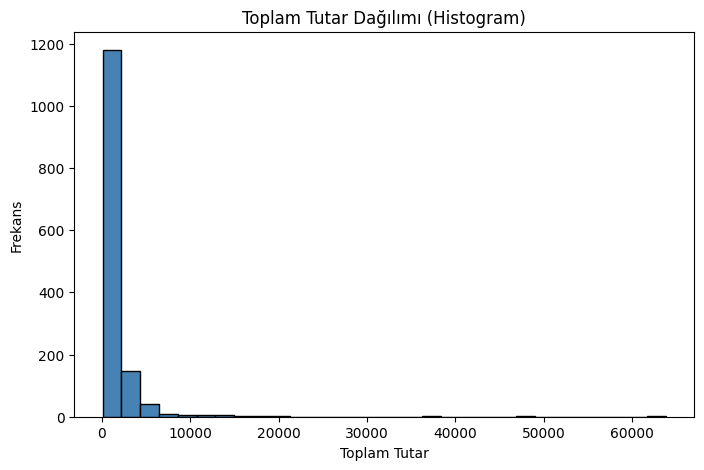

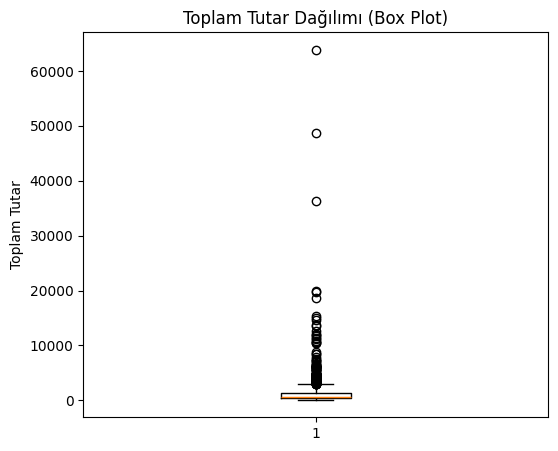

In [59]:
## SORU 14 - toplam_tutar için histogram ve box plot
plt.figure(figsize=(8, 5))
plt.hist(df_clean['toplam_tutar'], bins=30, color='steelblue', edgecolor='black')
plt.title('Toplam Tutar Dağılımı (Histogram)')
plt.xlabel('Toplam Tutar')
plt.ylabel('Frekans')
plt.show()

print("\n" + "\n")

plt.figure(figsize=(6, 5))
plt.boxplot(df_clean['toplam_tutar'])
plt.title('Toplam Tutar Dağılımı (Box Plot)')
plt.ylabel('Toplam Tutar')
plt.show()

kategori value_counts:
kategori
Kitap          253
Elektronik     241
Spor           235
Ofis           230
Kozmetik       223
Ev ve Yaşam    216
Name: count, dtype: int64

musteri_tipi yüzde dağılımı:
musteri_tipi
Mevcut    51.144492
Yeni      37.124464
VIP       11.731044
Name: proportion, dtype: float64




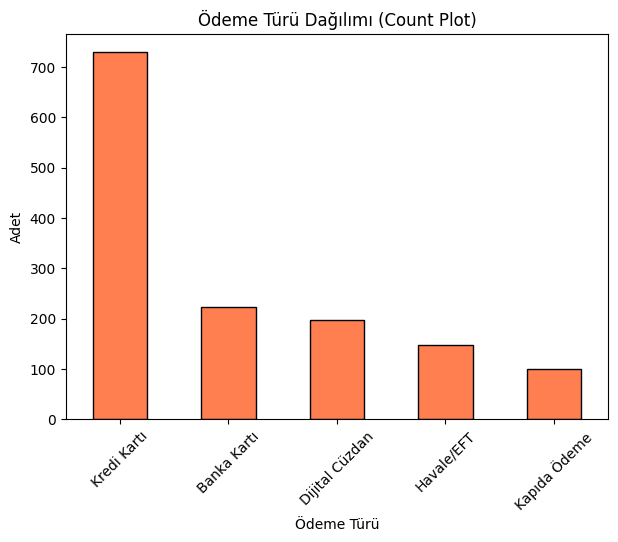


Temel istatistikler:
        birim_fiyat  toplam_tutar  musteri_puani
count   1398.000000   1398.000000    1398.000000
mean     660.712818   1377.934642       3.997854
std     1051.014558   2988.042747       1.071193
min       93.110000     89.680000       0.000000
25%      198.855000    327.190000       4.000000
50%      287.120000    670.965000       4.000000
75%      817.335000   1393.250000       5.000000
max    18145.230000  63870.200000       5.000000

En yüksek ortalama toplam_tutar'a sahip kategori: Elektronik
En yüksek ortalama musteri_puani'na sahip müşteri tipi: Mevcut


In [60]:
## SORU 15 - Kategorik ve sayısal analizler
print("kategori value_counts:")
print(df_clean['kategori'].value_counts())

print("\nmusteri_tipi yüzde dağılımı:")
print(df_clean['musteri_tipi'].value_counts(normalize=True) * 100)

plt.figure(figsize=(7, 5))
df_clean['odeme_turu'].value_counts().plot(kind='bar', color='coral', edgecolor='black')
plt.title('Ödeme Türü Dağılımı (Count Plot)')
plt.xlabel('Ödeme Türü')
plt.ylabel('Adet')
plt.xticks(rotation=45)
print("\n")
plt.show()

print("\nTemel istatistikler:")
print(df_clean[['birim_fiyat', 'toplam_tutar', 'musteri_puani']].describe())

en_yuksek_kategori = df_clean.groupby('kategori')['toplam_tutar'].mean().idxmax()
en_yuksek_musteri_tipi = df_clean.groupby('musteri_tipi')['musteri_puani'].mean().idxmax()

print("\nEn yüksek ortalama toplam_tutar'a sahip kategori:", en_yuksek_kategori)
print("En yüksek ortalama musteri_puani'na sahip müşteri tipi:", en_yuksek_musteri_tipi)

#### Yorum: Kategoriler arası ortalama harcamalar farklılık gösterirken, en yüksek tutar yukarıdaki kategoride, en yüksek müşteri memnuniyet puanını ise yukarıda görülen segment veriyor.